Hello Deena, welcome to my notebook showcasing my automl library. If you are interested you can look at the diagram in the chat.

The goal of the program is that the user can easily use advanced predifined or custom hypertuning and feature selection methods on their dataset.

The user needs to supply the target column as a string, the dataset as a df, as well as either choose from the predifined hypertuning and feature selection methods or make their own which uphold a interface.

The run_automl method first runs the feature selection function if defined. then the hypertuning method if defined.



In [1]:

import sys
import pandas as pd
from pathlib import Path

#the import process will be different if made like a true library
code = Path.cwd()/'code'
sys.path.append(str(code))
from automl.automl import SimpleAutoML
from Loss import mae, mape, r2
from feature_selection.forward import ForwardFeatureSelector
from feature_selection.backwards import BackwardFeatureSelector  
from hyper_tuning import GridSearchTuner, RandomSearchTuner, LineSearchTuner  
pd.options.display.max_columns = None



In [ ]:

data_path='data.csv'

df=pd.read_csv(data_path)
df=df.sample(frac=0.05, random_state=42) #5 percent of the data

df_clean=df.drop(columns=['dato'])
print(f"data shape {df_clean.shape}")

automl=SimpleAutoML()


data shape (76117, 21)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost


In [3]:
# a simple run through with no feature selection and no hyperparameter tuning

results = automl.run_automl( df=df_clean,
    target_col='Købesum', # target column
    feature_selection_fn=None, # how you specify no feature selection
    models_to_run=['linear_regression', 'xgboost'], # models we would like to include if we dont supply this then all valid models are chosen
    hypertuning_fn=None, # how you specify no hyperparameter tuning
    loss_fn=mae(), # loss function to use
    n_splits=5, # number of splits for cross-validation i use scikitlearn time series split
    test_split=0.1) # percentage of the data to use for testing

Data split - Train: 68505, Test: 7612
Training 2 models: ['linear_regression', 'xgboost']

Training linear_regression
  Using default parameters for linear_regression
linear_regression - Test mae: 1196648.85 (Features: 20)

Training xgboost
  Using default parameters for xgboost
xgboost - Test mae: 916447.56 (Features: 20)

AUTOML RESULTS
linear_regression: Test mae: 1,196,648.85
xgboost: Test mae: 916,447.56

Best Model: xgboost
Best Test mae: 916,447.56


In [4]:

save_path = automl.save_model('saved_models/Deenaexample1') # how we can save the model and specification like the scalar and columns we used

Model package saved to: saved_models/Deenaexample1.pkl
Model weights saved to: saved_models/Deenaexample1_xgboost.json


In [5]:
# example with feature selection
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=ForwardFeatureSelector,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=None,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running feature selection for xgboost
Starting forward feature selection with 20 available features
Added feature: mean_of_5_neighbors_pris, CV Score: 1075762.0250, Selected: 1
Added feature: pris_pr_m2_mean_365D_by, CV Score: 1027584.5375, Selected: 2
Added feature: age, CV Score: 999343.1250, Selected: 3
Added feature: m2, CV Score: 967741.4000, Selected: 4
Added feature: std_of_5_neighbors_pris_pr_m2, CV Score: 954004.0000, Selected: 5
Added feature: btype_Villa, CV Score: 942266.4750, Selected: 6
Added feature: btype_Fritidshus, CV Score: 935464.4250, Selected: 7
Added feature: omr_de_Hovedstaden__K_benhavn, CV Score: 930185.6000, Selected: 8
Added feature: date_ordinal, CV Score: 923547.8750, Selected: 9
Added feature: btype_R_kkehus, CV Score: 921699.9375, Selected: 10
Added feature: omr_de_Nordsj_lland, CV Score: 919865.1375, Selected: 11
Added feature: omr_de_Sydjylland

In [1]:
# another type of feature selection, cool huh? 

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=BackwardFeatureSelector,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=None,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

NameError: name 'automl' is not defined

In [7]:
# hypertuning

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=RandomSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 10 random parameter combinations
Best parameters: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 9}
Best CV score: 917946.0500
  Best params for xgboost: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 9}
xgboost - Test mae: 906513.25 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 10 random parameter combinations
Best parameters: {'model_type': 'ridge', 'alpha': 10.0}
Best CV score: 1188310.8808
  Best params for linear_regression: {'model_type': 'ridge', 'alpha': 10.0}
linear_regression - Test mae: 1196639.66 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 906,513.25
linear_regression: Test mae: 1,196,639.66

Best Model: xgboost
Best Test mae: 906,513.25


In [8]:
#not really made in a cool way, should be refactored, but it is possible to alter the parameters of the predifined functions.

def tuner( estimator, loss_fn, param_grid, cv, n_jobs, verbose,):
    return RandomSearchTuner(
        estimator=estimator,
        loss_fn=loss_fn,
        param_grid=param_grid, 
        cv=cv,
        n_iter=25,
        verbose=verbose # here we can directly change the number of iterations for the random search tuning
    )

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=tuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 25 random parameter combinations
Best parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6}
Best CV score: 916261.1375
  Best params for xgboost: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6}
xgboost - Test mae: 919365.50 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 25 random parameter combinations
Best parameters: {'model_type': 'ridge', 'alpha': 10.0}
Best CV score: 1188310.8808
  Best params for linear_regression: {'model_type': 'ridge', 'alpha': 10.0}
linear_regression - Test mae: 1196639.66 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 919,365.50
linear_regression: Test mae: 1,196,639.66

Best Model: xgboost
Best Test mae: 919,365.50


In [9]:
# two more examples with hypertuning
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=GridSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 12 parameter combinations
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV score: 981204.4125
  Best params for xgboost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
xgboost - Test mae: 998024.81 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 6 parameter combinations
Best parameters: {'alpha': 0.1, 'model_type': 'linear'}
Best CV score: 1188334.7955
  Best params for linear_regression: {'alpha': 0.1, 'model_type': 'linear'}
linear_regression - Test mae: 1196648.85 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 998,024.81
linear_regression: Test mae: 1,196,648.85

Best Model: xgboost
Best Test mae: 998,024.81


In [ ]:
#via the parameter param_amount we can specifiy how big of a parameter space we want to have
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=LineSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1,
    param_amount='big')

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Starting Line Search with initial params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}

 Pass 1/2
  New best for 'n_estimators': 750 -> Score: 960064.3000
  New best for 'learning_rate': 0.1 -> Score: 918657.4625
  New best for 'colsample_bytree': 1.0 -> Score: 917953.4500

 Pass 2/2
Stopping early, no improvement in a full pass.

Best parameters found: {'n_estimators': 750, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best CV score: 917953.4500
  Best params for xgboost: {'n_estimators': 750, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}
xgboost - Test mae: 922632.31 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Starting Line Search with initial params: {'mo

In [11]:
data_path='cleaned_data_harsh.csv'

df=pd.read_csv(data_path)

df_clean=df.drop(columns=['dato'])
print(f"data shape {df_clean.shape}")

automl=SimpleAutoML()


data shape (1522344, 21)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost


In [2]:
results = automl.run_automl( 
    df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None, 
    hypertuning_fn=LineSearchTuner, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.02, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

NameError: name 'automl' is not defined

In [3]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harsh.csv')
df_clean = df.drop(columns=['dato'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

# simple split - last 2% for testing
test_size = int(0.02 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('Købesum', axis=1)
y_train = train_data['Købesum']
X_test = test_data.drop('Købesum', axis=1)
y_test = test_data['Købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05, 
    max_depth=9,
    random_state=42
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()

train: 1,491,898, test: 30,446


KeyboardInterrupt: 

In [4]:

import numpy as np

df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df[df['btype'] == 'Ejerlejlighed']
df = df.drop(columns=['dato', 'btype'])
print(f"data shape {df.head}")

automl=SimpleAutoML()

for col in df.select_dtypes(include=[np.number]).columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=None, 
    hypertuning_fn=RandomSearchTuner, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.10, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

data shape <bound method NDFrame.head of           index  købesum  prev_købesum  price_change  price_change_pct  Vær.  \
406362        6  2115000           NaN           NaN               NaN     4   
143062        0   296270           NaN           NaN               NaN     3   
280216       27   210000           NaN           NaN               NaN     2   
156932       30   640000           NaN           NaN               NaN     3   
216377       33   325000           NaN           NaN               NaN     3   
...         ...      ...           ...           ...               ...   ...   
53874   2352544  3550000     2865000.0      685000.0         23.909250     2   
347877  2352623  1073000      675000.0      398000.0         58.962963     3   
220109  2352676  2225000     1750000.0      475000.0         27.142857     3   
348356  2352620  1675000     1280000.0      395000.0         30.859375     3   
347798  2352621  2498000     2273000.0      225000.0          9.898812     2   

In [2]:
import numpy as np

df = pd.read_csv('letsgo2.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'x', 'y', 'by','postnummer','pris_pr_m2'])
df = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

automl=SimpleAutoML()

for col in df.select_dtypes(include=[np.number]).columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=LineSearchTuner, 
    hypertuning_fn=None, 
    loss_fn=mape,
    n_splits=2,
    test_split=0.20, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

automl.save_model('saved_models/finaltest')

Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/linear_regression.py: Can't instantiate abstract class LinearRegressionConfig without an implementation for abstract method 'save_model'
Registered model: xgboost
Data split - Train: 1908171, Test: 477043
Training 1 models: ['xgboost']

Training xgboost
  Running feature selection for xgboost
xgboost failed: LineSearchTuner.__init__() missing 1 required positional argument: 'param_grid'


ValueError: No valid models found

train: 327,972, test: 81,993
overall mape: 3.8%


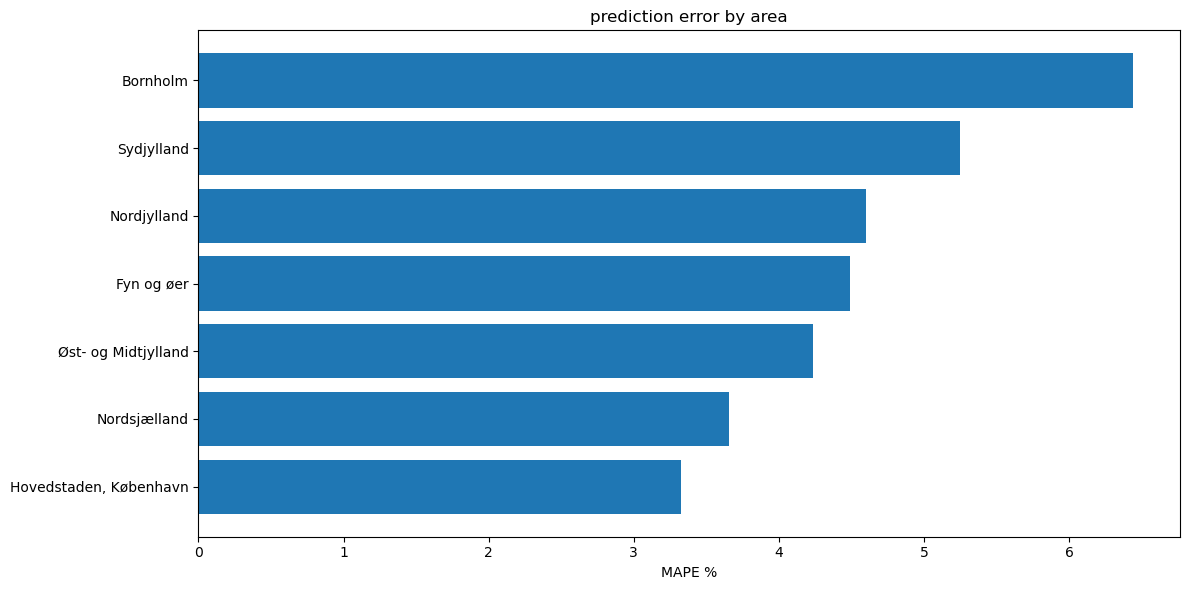


By area:
                  area     mape  count
Hovedstaden, København 3.325671  41939
          Nordsjælland 3.654350   5313
   Øst- og Midtjylland 4.232340  13418
            Fyn og øer 4.491753   3567
           Nordjylland 4.602059   5675
            Sydjylland 5.246625   5552
              Bornholm 6.441387     50


In [15]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df_clean = df.drop(columns=['dato','pris_pr_m2_temp'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05, 
    max_depth=9,
    random_state=42
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()


print(f"\nBy area:")
print(results_df.to_string(index=False))

In [14]:
df.sample(20)

,Unnamed: 0,dato,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,pris_pr_m2_temp,pris_pr_m2_prev,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale,num_neighbors_used_5,mean_of_5_neighbors_pris_pr_m2,num_neighbors_used_15,mean_of_15_neighbors_pris_pr_m2,num_neighbors_used_30,mean_of_30_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_by,historical_premium_vs_by_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,mean_of_5_neighbors_pris
287855,287855,2020-09-10 22:00:00+00:00,1400000,NaN,NaN,NaN,4,82.0,17073.170732,NaN,16885.652210,16885.652210,NaN,NaN,NaN,5,14160.042731,6,14235.933045,6,14235.933045,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.167347e+06,1.161124e+06
343935,343935,2003-04-30 22:00:00+00:00,631254,NaN,NaN,NaN,3,102.0,6188.764706,NaN,9716.485297,9716.485297,NaN,NaN,NaN,1,14833.333333,1,14833.333333,1,14833.333333,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,1.513000e+06,1.513000e+06
174211,174211,2018-11-01 23:00:00+00:00,1975000,1450000.0,525000.0,36.206897,2,60.0,32916.666667,24166.666667,27446.063116,27446.063116,19400.552288,19400.552288,1005.0,5,28959.523810,9,28617.724868,9,28617.724868,4766.114379,24.566901,4766.114379,24.566901,0,0,1,0,0,0,0,1.717063e+06,1.737571e+06
15053,15053,2017-09-30 22:00:00+00:00,1495000,999000.0,496000.0,49.649650,2,48.0,31145.833333,20812.500000,25349.528767,25349.528767,18841.975951,18841.975951,792.0,5,25602.781313,9,25781.977310,9,25781.977310,1970.524049,10.458160,1970.524049,10.458160,0,0,1,0,0,0,0,1.237535e+06,1.228934e+06
274726,274726,2021-12-06 23:00:00+00:00,490000,NaN,NaN,NaN,1,39.0,12564.102564,NaN,18576.305171,18576.305171,NaN,NaN,NaN,5,11310.219250,9,11147.137975,9,11147.137975,NaN,NaN,NaN,NaN,0,1,0,0,0,0,0,4.347384e+05,4.410986e+05
409009,409009,2022-07-10 22:00:00+00:00,4050000,NaN,NaN,NaN,3,80.0,50625.000000,NaN,41579.131205,41579.131205,NaN,NaN,NaN,5,47549.193877,15,44199.402713,30,43117.652041,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,3.449412e+06,3.803936e+06
337710,337710,1998-02-14 23:00:00+00:00,694600,NaN,NaN,NaN,2,72.0,9647.222222,NaN,10731.001264,10731.001264,NaN,NaN,NaN,4,11712.406430,4,11712.406430,4,11712.406430,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,8.432933e+05,8.432933e+05
362596,362596,2016-11-15 23:00:00+00:00,925000,810000.0,115000.0,14.197531,3,76.0,12171.052632,10657.894737,11086.596382,11086.596382,12191.919625,12191.919625,1629.0,5,10079.515015,7,10234.981628,7,10234.981628,-1534.024888,-12.582308,-1534.024888,-12.582308,0,0,0,0,0,0,1,7.778586e+05,7.660431e+05
309260,309260,1996-10-09 22:00:00+00:00,215000,NaN,NaN,NaN,2,43.0,5000.000000,NaN,6853.308979,6853.308979,NaN,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN
2378,2378,2010-09-30 22:00:00+00:00,1485000,NaN,NaN,NaN,3,59.0,25169.491525,NaN,23824.181403,23824.181403,NaN,NaN,NaN,5,23087.340382,5,23087.340382,5,23087.340382,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,1.362153e+06,1.362153e+06


train: 1,882,192, test: 470,547
overall mape: 38.2%

By building type:
        btype      mape  count
Ejerlejlighed 16.407627  83879

By building type:
        btype      mape  count
Ejerlejlighed 16.407627  83879
   Fritidshus 44.707046  65857

By building type:
        btype      mape  count
Ejerlejlighed 16.407627  83879
   Fritidshus 44.707046  65857
  Landejendom 79.342725  16489

By building type:
        btype      mape  count
Ejerlejlighed 16.407627  83879
     Rækkehus 22.880815  39679
   Fritidshus 44.707046  65857
  Landejendom 79.342725  16489

By building type:
        btype      mape  count
Ejerlejlighed 16.407627  83879
     Rækkehus 22.880815  39679
        Villa 43.163972 264643
   Fritidshus 44.707046  65857
  Landejendom 79.342725  16489


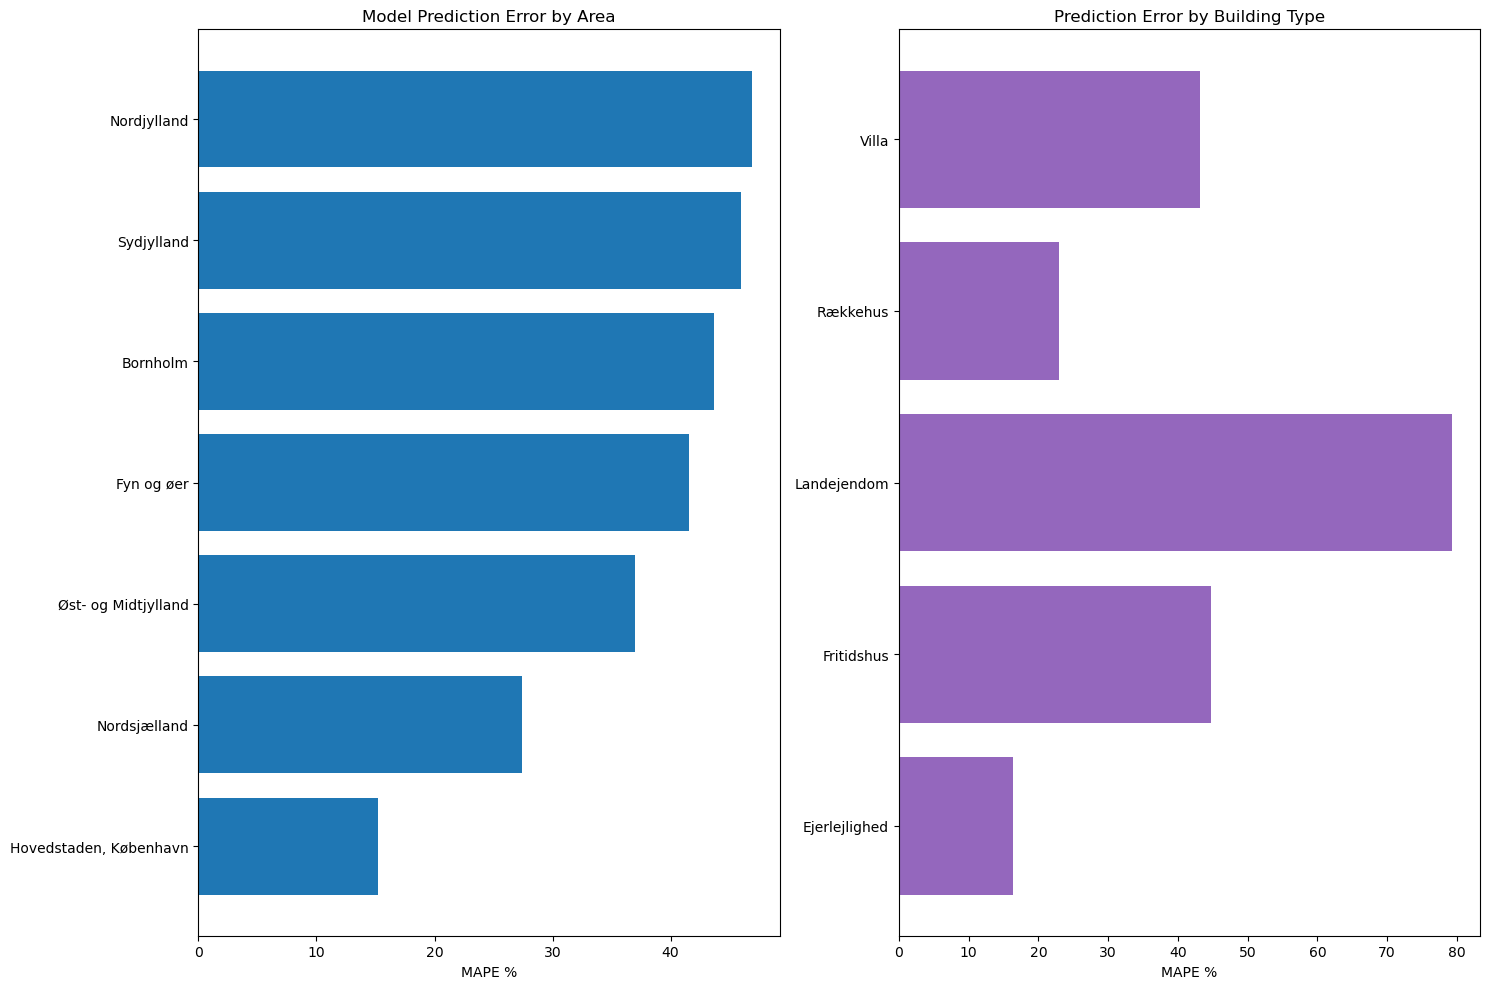


By area:
                  area      mape  count
Hovedstaden, København 15.250795  60462
          Nordsjælland 27.412710  32101
   Øst- og Midtjylland 36.984618  77494
            Fyn og øer 41.583269  42296
              Bornholm 43.702786   5746
            Sydjylland 45.929064 111927
           Nordjylland 46.889588  54051


In [16]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')

df = df.drop(columns=['dato', 'price_change', 'price_change_pct'])

df_clean = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6,
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Model Prediction Error by Area')

btype_cols = [col for col in test_data.columns if 'btype.' in col]

if btype_cols:  # if we have building type columns
    btype_results = []

for col in btype_cols:
    btype_data = test_data[test_data[col] == 1]
    if len(btype_data) > 5:
        btype_name = col.replace('btype.', '')
        btype_actual = y_test[test_data[col] == 1]
        btype_preds = preds[test_data[col] == 1]
        btype_mape = mape(btype_actual, btype_preds)
        btype_results.append([btype_name, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [8]:
df.head(10)

,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,btype,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_pris
1916951,18,660000,NaN,NaN,NaN,4,159.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1474057,5,1100000,NaN,NaN,NaN,4,108.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1564890,9,450000,NaN,NaN,NaN,4,101.0,Fritidshus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1461534,20,350000,NaN,NaN,NaN,4,66.0,Fritidshus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1035763,1,250000,NaN,NaN,NaN,5,65.0,Fritidshus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1979799,10,895000,NaN,NaN,NaN,8,180.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1188337,3,215000,NaN,NaN,NaN,4,79.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
406362,6,2115000,NaN,NaN,NaN,4,122.0,Ejerlejlighed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
497783,4,1355000,NaN,NaN,NaN,5,152.0,Rækkehus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1549568,21,1050000,NaN,NaN,NaN,9,260.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN


train: 1,882,191, test: 470,547
overall mape: 11.1%


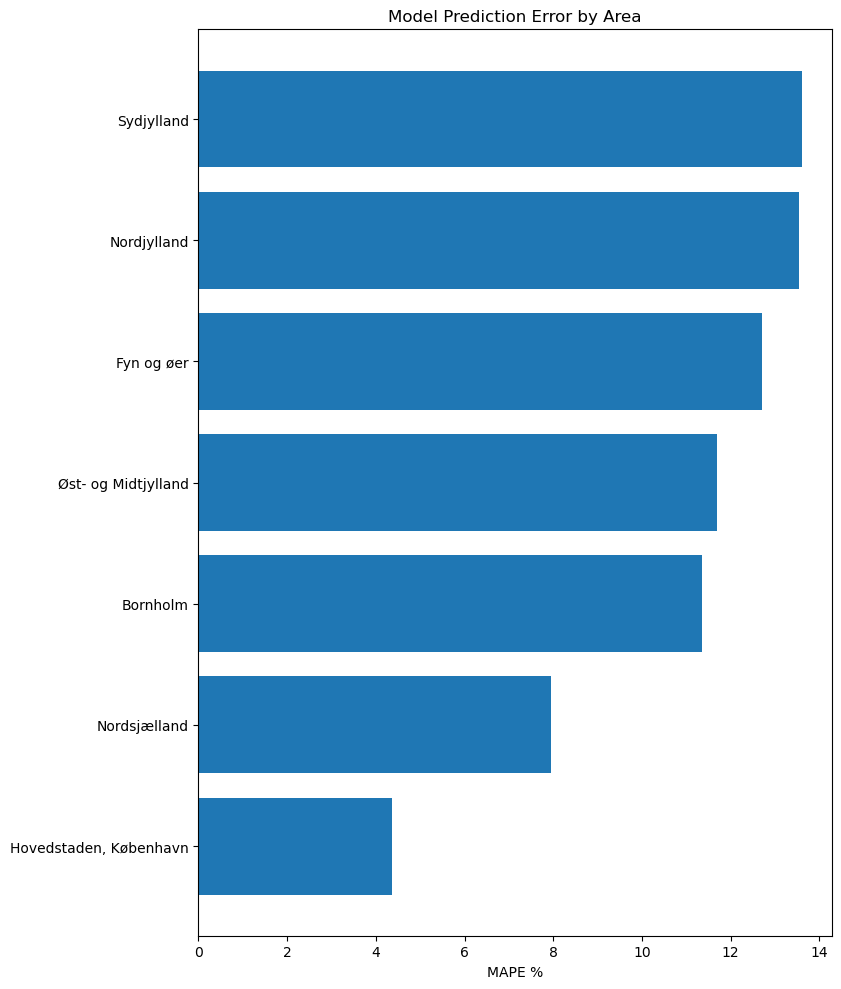


By area:
                  area      mape  count
Hovedstaden, København  4.374491  60461
          Nordsjælland  7.958416  32101
              Bornholm 11.350431   5746
   Øst- og Midtjylland 11.695091  77494
            Fyn og øer 12.712329  42297
           Nordjylland 13.538534  54051
            Sydjylland 13.597618 111927


In [10]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df[df['btype'] == 'Ejerlejlighed']
df = df.drop(columns=['dato', 'price_change', 'price_change_pct', 'btype'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03, 
    max_depth=9,
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Model Prediction Error by Area')

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [11]:
df.sample(10)

,index,købesum,prev_købesum,Vær.,m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_pris
344184,1937052,1770000,1600000.0,3,78.0,23490.403337,21196.503981,20512.820513,19743.075703,19625.495107,1835.0,5.0,25667.986338,5.0,25667.986338,7.0,24532.818572,6.0,25437.607662,7.0,24532.818572,6.0,25437.607662,769.744810,3.898809,887.325406,4.521289,0,0,0,0,0,0,1,1.913560e+06,1.832251e+06,1.903687e+06,1.653327e+06,1.728079e+06,2.002103e+06
235465,814930,995000,445000.0,2,62.0,12143.168505,15136.225937,7177.419355,5278.549088,6835.989553,4505.0,5.0,15816.129032,5.0,15816.129032,6.0,15767.826825,6.0,15767.826825,6.0,15767.826825,6.0,15767.826825,1898.870267,35.973337,341.429802,4.994592,0,0,0,0,0,0,0,9.776053e+05,7.528764e+05,1.023711e+06,9.384460e+05,9.853176e+05,9.806000e+05
4198,659352,665480,NaN,1,35.0,14359.831473,14899.104480,NaN,NaN,NaN,NaN,5.0,13675.567012,5.0,13675.567012,9.0,13608.296423,9.0,13608.296423,9.0,13608.296423,9.0,13608.296423,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,4.762904e+05,5.025941e+05,NaN,5.214687e+05,NaN,4.786448e+05
364324,913893,175000,148000.0,1,45.0,6248.758808,6006.980636,3288.888889,4842.302479,4024.140523,2721.0,5.0,5445.569778,5.0,5445.569778,9.0,5580.344731,9.0,5580.344731,9.0,5580.344731,9.0,5580.344731,-1553.413590,-32.080061,-735.251634,-18.271023,0,0,0,0,0,0,1,2.511155e+05,2.811941e+05,1.909869e+05,2.703141e+05,2.209250e+05,2.450506e+05
414226,1758399,3639181,NaN,4,112.0,25790.005915,26166.359163,NaN,NaN,NaN,NaN,5.0,14069.590296,5.0,27106.851422,15.0,21850.895071,15.0,27737.032561,30.0,25848.951790,30.0,28718.607771,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,2.895083e+06,2.888481e+06,NaN,2.930632e+06,NaN,1.575794e+06
48359,2246233,2980000,1595000.0,3,68.0,48525.068438,48525.068438,23455.882353,24197.697474,24251.507499,3586.0,5.0,44225.150757,5.0,44225.150757,10.0,47455.271440,10.0,47455.271440,10.0,47455.271440,10.0,47455.271440,-741.815121,-3.065643,-795.625146,-3.280724,0,0,1,0,0,0,0,3.226958e+06,3.299705e+06,3.198547e+06,3.299705e+06,3.191450e+06,3.007310e+06
137085,2242271,2595000,1450000.0,2,61.0,34295.617583,34762.253597,23770.491803,23520.427402,21949.268784,3416.0,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,250.064402,1.063180,1821.223019,8.297420,0,0,1,0,0,0,0,2.322894e+06,2.092033e+06,2.114275e+06,2.120497e+06,2.296444e+06,2.322894e+06
71204,699747,1315000,600000.0,2,60.0,17493.259032,17493.259032,10000.000000,18204.950609,18204.950609,317.0,5.0,15851.636119,5.0,15851.636119,12.0,17922.737351,12.0,17922.737351,12.0,17922.737351,12.0,17922.737351,-8204.950609,-45.069887,-8204.950609,-45.069887,0,0,1,0,0,0,0,1.075364e+06,1.049596e+06,5.765440e+05,1.049596e+06,5.765440e+05,9.510982e+05
148485,1934453,2925000,2700000.0,4,86.0,31051.979510,29918.736400,31395.348837,27776.545854,27304.356264,771.0,5.0,31083.375540,5.0,31083.375540,10.0,32690.912576,10.0,32690.912576,10.0,32690.912576,10.0,32690.912576,3618.802984,13.028269,4090.992573,14.982930,0,0,1,0,0,0,0,2.811418e+06,2.670470e+06,3.018386e+06,2.57301

In [3]:
import numpy as np

df = pd.read_csv('letsgo2.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'x', 'y', 'by','postnummer','pris_pr_m2'])
df = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

automl=SimpleAutoML()

for col in df.select_dtypes(include=[np.number]).columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=None, 
    hypertuning_fn=None, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.20, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

automl.save_model('saved_models/finaltest')

Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/linear_regression.py: Can't instantiate abstract class LinearRegressionConfig without an implementation for abstract method 'save_model'
Registered model: xgboost
Data split - Train: 1908171, Test: 477043
Training 1 models: ['xgboost']

Training xgboost
  Using default parameters for xgboost
xgboost - Test mape: 0.34 (Features: 36)

AUTOML RESULTS
xgboost: Test mape: 0.34

Best Model: xgboost
Best Test mape: 0.34
Model package saved to: saved_models/finaltest.pkl
Model weights saved to: saved_models/finaltest_xgboost.json


'saved_models/finaltest.pkl'

  - område_Hovedstaden__København
  - btype.Fritidshus
  - område_Øst_og_Midtjylland
  - btype.Villa
  - btype.Rækkehus
Original dataframe shape: (2510019, 55)
Selected dataframe shape: (2510019, 17)
train: 2,008,016, test: 502,003
overall mape: 43.7%

By building type:
        btype      mape  count
Ejerlejlighed 20.070804  98814

By building type:
        btype      mape  count
Ejerlejlighed 20.070804  98814
   Fritidshus 48.998907  61643

By building type:
        btype       mape  count
Ejerlejlighed  20.070804  98814
   Fritidshus  48.998907  61643
  Landejendom 134.452657  19990

By building type:
        btype       mape  count
Ejerlejlighed  20.070804  98814
     Rækkehus  27.717169  42712
   Fritidshus  48.998907  61643
  Landejendom 134.452657  19990

By building type:
        btype       mape  count
Ejerlejlighed  20.070804  98814
     Rækkehus  27.717169  42712
        Villa  46.782151 278844
   Fritidshus  48.998907  61643
  Landejendom 134.452657  19990


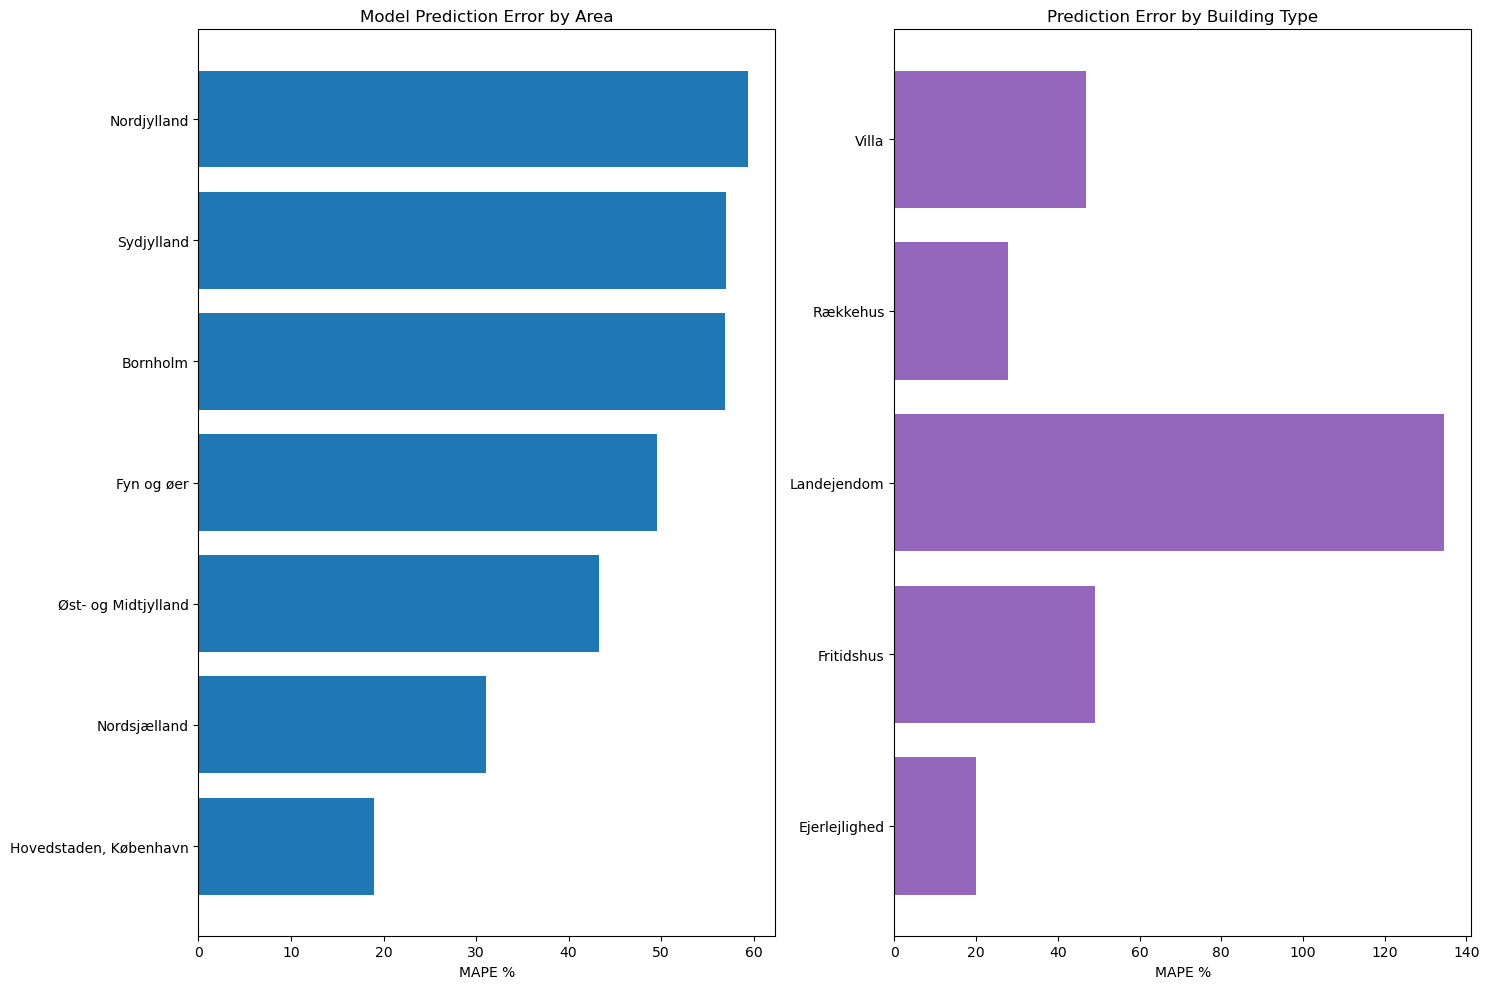


By area:
                  area      mape  count
Hovedstaden, København 19.008193  96056
          Nordsjælland 31.119883  37661
   Øst- og Midtjylland 43.310425  80627
            Fyn og øer 49.506126  40636
              Bornholm 56.932721   5228
            Sydjylland 57.040717 106371
           Nordjylland 59.352788  51487


In [4]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertesttesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'x', 'y', 'index', 'by','postnummer', 'pris_pr_grundareal_m2'])
df_clean = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6,
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Model Prediction Error by Area')

btype_cols = [col for col in test_data.columns if 'btype.' in col]

if btype_cols:  # if we have building type columns
    btype_results = []

for col in btype_cols:
    btype_data = test_data[test_data[col] == 1]
    if len(btype_data) > 5:
        btype_name = col.replace('btype.', '')
        btype_actual = y_test[test_data[col] == 1]
        btype_preds = preds[test_data[col] == 1]
        btype_mape = mape(btype_actual, btype_preds)
        btype_results.append([btype_name, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [7]:
df.tail()

,Unnamed: 0,købesum,prev_købesum,Vær.,m2,btype,grundareal_total,vejareal_total,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,mean_of_5_neighbors_pris_pr_grundareal_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,historical_grundareal_premium_vs_postnummer,historical_grundareal_premium_vs_postnummer_pct,historical_grundareal_premium_vs_btype_postnummer,historical_grundareal_premium_vs_btype_postnummer_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,floor_numeric,mean_of_5_neighbors_pris,mean_of_5_samebtype_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_grundareal_pris,mean_of_5_samebtype_neighbors_grundareal_pris,postnummer_grundareal_pris_estimate,postnummer_grundareal_pris_premium_adjusted,postnummer_btype_grundareal_pris_estimate,postnummer_btype_grundareal_pris_premium_adjusted
520114,520114,4900000,2795000.0,4,106.0,Villa,721.0,0.0,39241.021686,39343.986903,9172.403431,7632.974054,6.801887,26367.924528,18422.081254,17838.179641,3876.560333,4288.865163,3622.215282,12229,6302.0,3,52727.748546,7317.504444,3,52727.748546,7317.504444,7945.843275,43.132169,8529.744887,47.817351,-412.304830,-9.613378,254.345051,7.021809,0,0,1,0,0,0,0,NaN,5.589141e+06,5.589141e+06,4.159548e+06,5.953652e+06,4.170463e+06,6.164667e+06,5.275921e+06,5.275921e+06,6.613303e+06,5.977541e+06,5.503374e+06,5.889811e+06
2313310,2313310,2398000,530000.0,4,175.0,Villa,5500.0,0.0,11110.019726,10153.373761,825.756682,822.846712,31.428571,3028.571429,5994.418204,5418.834924,96.363636,527.280354,519.587807,12229,7426.0,1,7838.283828,450.493171,1,7838.283828,450.493171,-2965.846776,-49.476808,-2390.263495,-44.110284,-430.916718,-81.724402,-423.224170,-81.453830,0,0,0,0,0,1,0,NaN,1.371700e+06,1.371700e+06,1.944253e+06,9.822989e+05,1.776840e+06,9.930711e+05,2.477712e+06,2.477712e+06,4.541662e+06,8.300158e+05,4.525657e+06,8.393360e+05
1183890,1183890,470880,1385000.0,6,190.0,Villa,5576.0,76.0,12545.477827,6969.149391,782.730387,916.827842,29.347368,7289.473684,7255.776829,5743.259307,248.385940,676.500822,845.864783,12229,4670.0,0,NaN,NaN,0,NaN,NaN,33.696855,0.464414,1546.214377,26.922246,-428.114882,-63.283719,-597.478843,-70.635266,0,0,0,1,0,0,0,NaN,NaN,NaN,2.383641e+06,2.394711e+06,1.324138e+06,1.680626e+06,NaN,NaN,4.364505e+06,1.602484e+06,5.112232e+06,1.501193e+06
2022531,2022531,1725000,1450000.0,5,126.0,Villa,880.0,0.0,15216.988057,14396.739493,3050.608954,3028.313150,6.984127,11507.936508,15220.945408,13804.536692,1647.727273,3088.632215,2719.050624,12229,799.0,3,10318.147498,1804.792610,3,10318.147498,1804.792610,-3713.008900,-24.394075,-2296.600184,-16.636561,-1440.904942,-46.651878,-1071.323351,-39.400640,0,0,0,0,0,1,0,NaN,1.300087e+06,1.300087e+06,1.917340e+06,1.449623e+06,1.813989e+06,1.512204e+06,1.588217e+06,1.588217e+06,2.684536e+06,1.432149e+06,2.664916e+06,1.614922e+06
1324245,1324245,7300000,5000000.0,5,158.0,Villa,1025.0,0.0,23651.908808,22313.009653,4656.870732,4248.350739,6.487342,31645.569620,22290.372338,20592.844068,4878.048780,4406.089718,3748.472147,12229,977.0,3,16443.573989,5083.667167,2,15015.360983,3368.147809,9355.197282,41.969677,11052.725553,53.672652,471.

train: 1,908,172, test: 477,042
overall mape: 33.9%

By building type:
        btype      mape  count
Ejerlejlighed 13.420472  95299

By building type:
        btype      mape  count
Ejerlejlighed 13.420472  95299
   Fritidshus 37.066721  55482

By building type:
        btype       mape  count
Ejerlejlighed  13.420472  95299
   Fritidshus  37.066721  55482
  Landejendom 101.892824  15065

By building type:
        btype       mape  count
Ejerlejlighed  13.420472  95299
     Rækkehus  20.203794  41345
   Fritidshus  37.066721  55482
  Landejendom 101.892824  15065

By building type:
        btype       mape  count
Ejerlejlighed  13.420472  95299
     Rækkehus  20.203794  41345
   Fritidshus  37.066721  55482
        Villa  38.755844 269851
  Landejendom 101.892824  15065


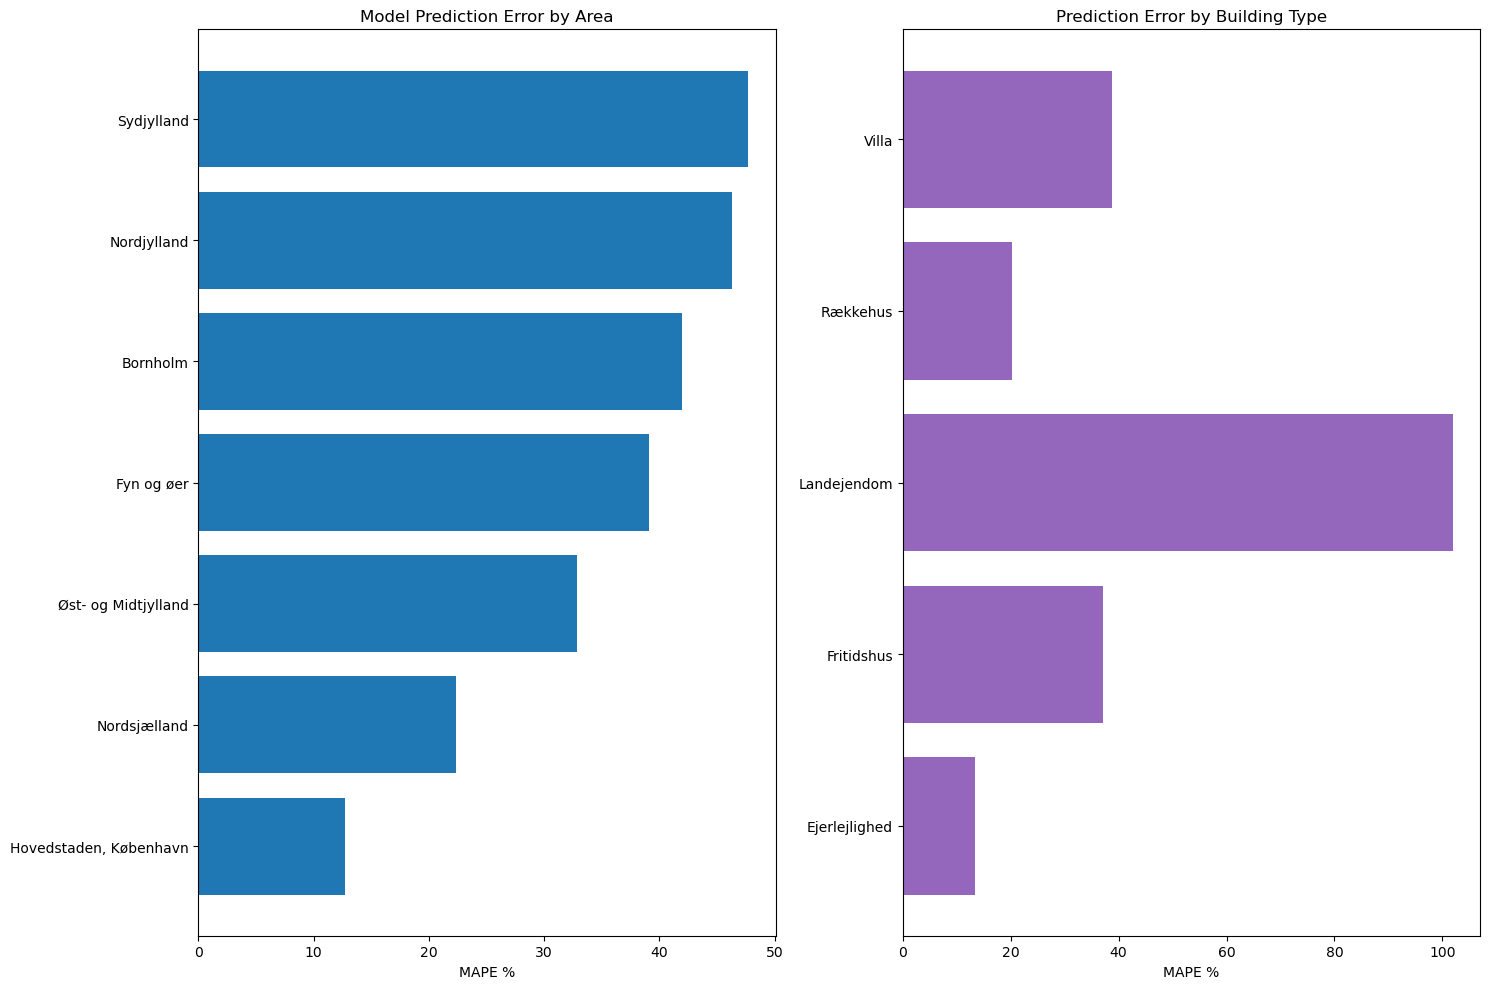


By area:
                  area      mape  count
Hovedstaden, København 12.691760  90701
          Nordsjælland 22.348351  35426
   Øst- og Midtjylland 32.834599  77288
            Fyn og øer 39.069387  38350
              Bornholm 41.942401   4845
           Nordjylland 46.286386  49336
            Sydjylland 47.708953 101304


In [3]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('letsgo2.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'x', 'y', 'by','postnummer','pris_pr_m2'])

df_clean = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6,
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Model Prediction Error by Area')

btype_cols = [col for col in test_data.columns if 'btype.' in col]

if btype_cols:  # if we have building type columns
    btype_results = []

for col in btype_cols:
    btype_data = test_data[test_data[col] == 1]
    if len(btype_data) > 5:
        btype_name = col.replace('btype.', '')
        btype_actual = y_test[test_data[col] == 1]
        btype_preds = preds[test_data[col] == 1]
        btype_mape = mape(btype_actual, btype_preds)
        btype_results.append([btype_name, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

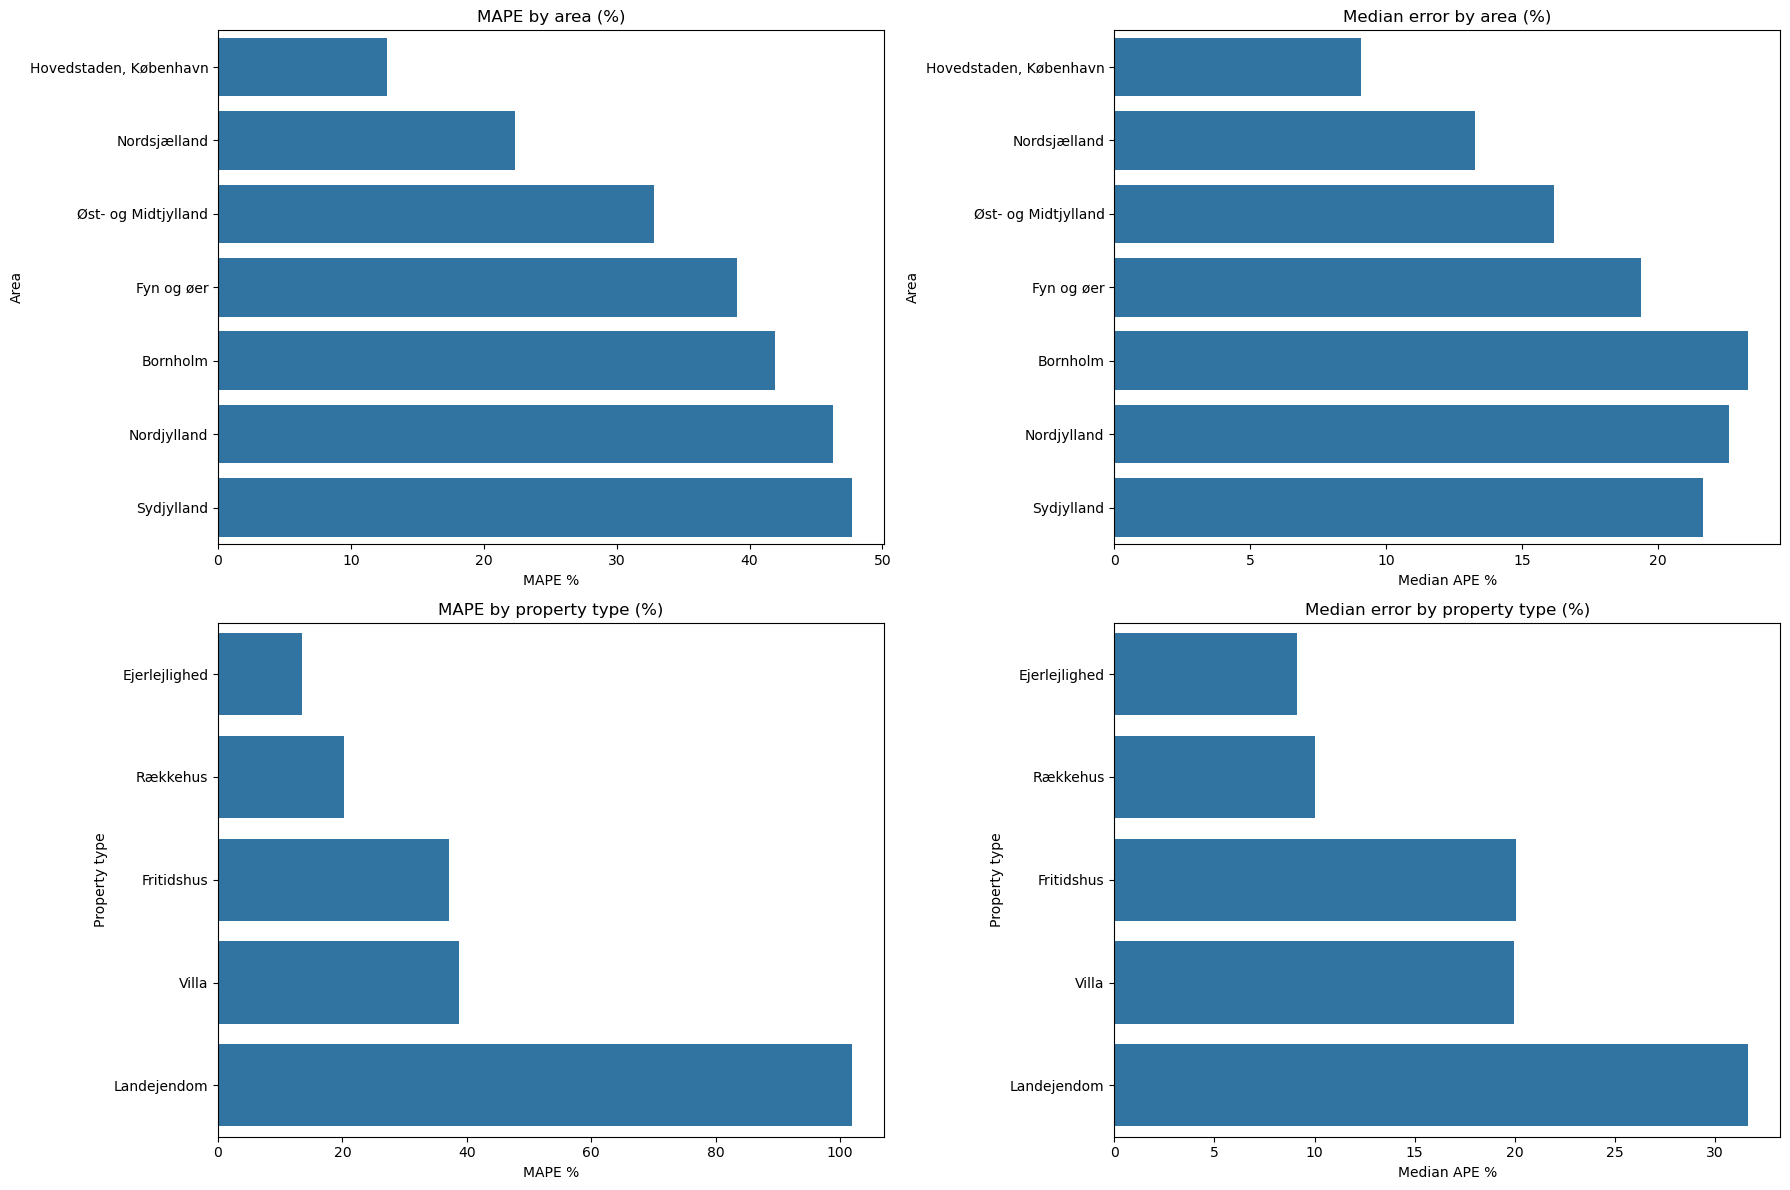

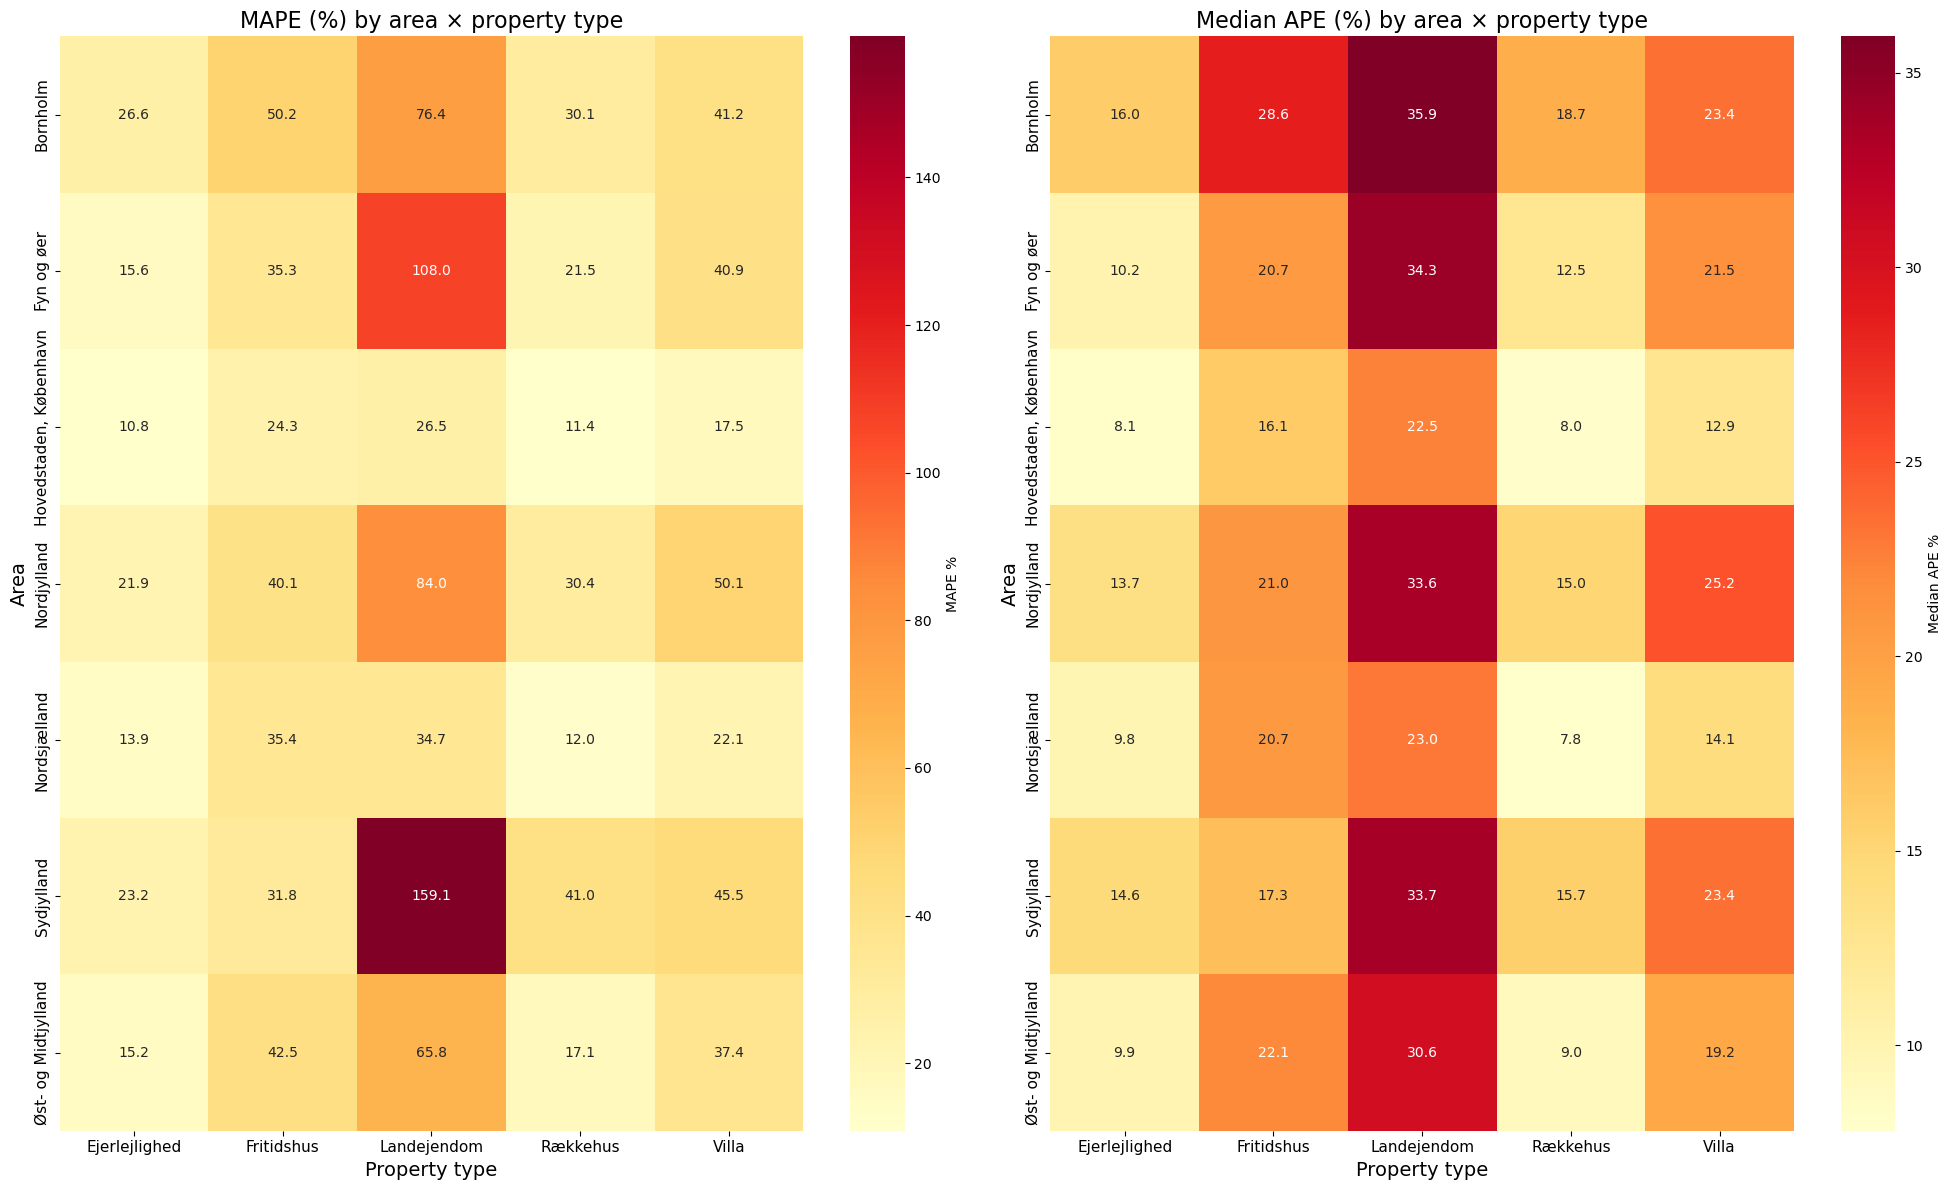


median vs mean error comparison:
Overall MAPE: 33.9%
Overall median APE: 16.1%
Mean MAPE by area: 34.7%
Mean median APE by area: 17.9%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def median_ape(actual, pred):
    return np.median(np.abs((actual - pred) / actual)) * 100

area_results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        area_median = median_ape(area_actual, area_preds)
        area_results.append([area_name, area_mape, area_median, len(area_actual)])

area_results_df = pd.DataFrame(area_results, columns=['Area', 'mape', 'median_ape', 'count'])
area_results_df = area_results_df.sort_values('mape')

property_type_results = []
for col in btype_cols:
    property_type_data = test_data[test_data[col] == 1]
    if len(property_type_data) > 5:
        property_type_name = col.replace('btype.', '')
        property_type_actual = y_test[test_data[col] == 1]
        property_type_preds = preds[test_data[col] == 1]
        property_type_mape = mape(property_type_actual, property_type_preds)
        property_type_median = median_ape(property_type_actual, property_type_preds)
        property_type_results.append([property_type_name, property_type_mape, property_type_median, len(property_type_actual)])

property_type_results_df = pd.DataFrame(property_type_results, columns=['Property type', 'mape', 'median_ape', 'count'])
property_type_results_df = property_type_results_df.sort_values('mape')

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.barplot(y='Area', x='mape', data=area_results_df)
plt.title('MAPE by area (%)')
plt.xlabel('MAPE %')
plt.tight_layout()

plt.subplot(2, 2, 2)
sns.barplot(y='Area', x='median_ape', data=area_results_df)
plt.title('Median error by area (%)')
plt.xlabel('Median APE %')
plt.tight_layout()

plt.subplot(2, 2, 3)
sns.barplot(y='Property type', x='mape', data=property_type_results_df)
plt.title('MAPE by property type (%)')
plt.xlabel('MAPE %')
plt.tight_layout()

plt.subplot(2, 2, 4)
sns.barplot(y='Property type', x='median_ape', data=property_type_results_df)
plt.title('Median error by property type (%)')
plt.xlabel('Median APE %')
plt.tight_layout()

plt.tight_layout()

plt.show()

area_property_type_errors = []
for area_col in area_cols:
    area_mask = test_data[area_col] == 1
    if area_mask.sum() > 5:
        area_name = area_col.replace('område_', '')
        for btype_col in btype_cols:
            property_type_mask = test_data[btype_col] == 1
            combined_mask = area_mask & property_type_mask
            if combined_mask.sum() >= 5:
                actual = y_test[combined_mask]
                pred = preds[combined_mask]
                area_property_type_mape = mape(actual, pred)
                area_property_type_median = median_ape(actual, pred)
                area_property_type_errors.append([
                    area_name, btype_col.replace('btype.', ''),
                    area_property_type_mape, area_property_type_median, combined_mask.sum()
                ])

cross_results_df = pd.DataFrame(
    area_property_type_errors,
    columns=['Area', 'Property type', 'mape', 'median_ape', 'count']
)

mape_matrix = pd.pivot_table(
    cross_results_df, values='mape',
    index='Area', columns='Property type', fill_value=np.nan
)

median_matrix = pd.pivot_table(
    cross_results_df, values='median_ape',
    index='Area', columns='Property type', fill_value=np.nan
)

fig, axs = plt.subplots(1, 2, figsize=(20, 12))

sns.heatmap(mape_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axs[0], cbar_kws={'label': 'MAPE %'})
axs[0].set_title('MAPE (%) by area × property type', fontsize=16)
axs[0].set_xlabel('Property type', fontsize=14)
axs[0].set_ylabel('Area', fontsize=14)
axs[0].tick_params(axis='x', labelsize=11)
axs[0].tick_params(axis='y', labelsize=11)

sns.heatmap(median_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axs[1], cbar_kws={'label': 'Median APE %'})
axs[1].set_title('Median APE (%) by area × property type', fontsize=16)
axs[1].set_xlabel('Property type', fontsize=14)
axs[1].set_ylabel('Area', fontsize=14)
axs[1].tick_params(axis='x', labelsize=11)
axs[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

print("\nmedian vs mean error comparison:")
print(f"Overall MAPE: {mape(y_test, preds):.1f}%")
print(f"Overall median APE: {median_ape(y_test, preds):.1f}%")
print(f"Mean MAPE by area: {area_results_df['mape'].mean():.1f}%")
print(f"Mean median APE by area: {area_results_df['median_ape'].mean():.1f}%")

In [ ]:
area_median_table = area_results_df[['area', 'median_ape']].groupby('area').median().sort_values('median_ape')
print("\nMedian APE by area:")
print(area_median_table)

btype_median_table = btype_results_df[['btype', 'median_ape']].groupby('btype').median().sort_values('median_ape')
print("\nMedian APE by property type:")
print(btype_median_table)


Median APE by area:
                        median_ape
area                              
Hovedstaden, København    9.083377
Nordsjælland             13.270075
Øst- og Midtjylland      16.187962
Fyn og øer               19.367013
Sydjylland               21.648643
Nordjylland              22.630963
Bornholm                 23.327939

Median APE by property type:
               median_ape
btype                    
Ejerlejlighed    9.100261
Rækkehus        10.037373
Villa           19.985933
Fritidshus      20.078836
Landejendom     31.664652


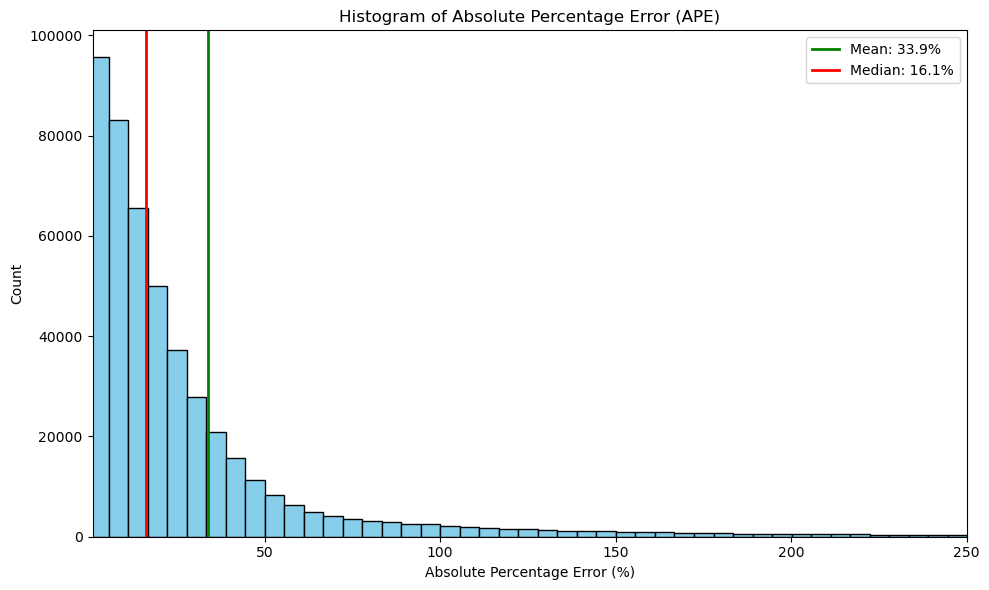

In [ ]:


ape_errors = np.abs((preds - y_test) / y_test) * 100

plt.figure(figsize=(10, 6))
plt.hist(ape_errors, bins=50000, color='skyblue', edgecolor='black')  # R
plt.xlim(1, 250) 
plt.ylim(0,101000)
mean_ape = np.mean(ape_errors)
median_ape = np.median(ape_errors)

plt.axvline(mean_ape, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_ape:.1f}%')
plt.axvline(median_ape, color='red', linestyle='-', linewidth=2, label=f'Median: {median_ape:.1f}%')

plt.xlabel('Absolute Percentage Error (%)')
plt.ylabel('Count')
plt.title('Histogram of Absolute Percentage Error (APE)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ape_errors = np.abs((preds - y_test) / y_test) * 100


# Print error statistics
print(f"Error statistics:")
print(f"  Mean error: {np.mean(ape_errors):.1f}%")
print(f"  Median error: {np.median(ape_errors):.1f}%")
print(f"  90th percentile: {np.percentile(ape_errors, 90):.1f}%")
print(f"  95th percentile: {np.percentile(ape_errors, 95):.1f}%")
print(f"  99th percentile: {np.percentile(ape_errors, 99):.1f}%")
print(f"  Max error: {np.max(ape_errors):.1f}%")

In [ ]:
import numpy as np

df = pd.read_csv('letsgo2.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'x', 'y', 'by','postnummer','pris_pr_m2'])
df = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

automl=SimpleAutoML()

for col in df.select_dtypes(include=[np.number]).columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=None, 
    hypertuning_fn=None, 
    loss_fn=r2(),
    n_splits=5,
    test_split=0.10, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

automl.save_model('saved_models/finaltest')

Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/linear_regression.py: Can't instantiate abstract class LinearRegressionConfig without an implementation for abstract method 'save_model'
Registered model: xgboost
Data split - Train: 2146692, Test: 238522
Training 1 models: ['xgboost']

Training xgboost
  Using default parameters for xgboost
xgboost - Test r2: 0.85 (Features: 36)

AUTOML RESULTS
xgboost: Test r2: 0.85

Best Model: xgboost
Best Test r2: 0.85
Model package saved to: saved_models/finaltest.pkl
Model weights saved to: saved_models/finaltest_xgboost.json


'saved_models/finaltest.pkl'